<a href="https://colab.research.google.com/github/sindhura-nk/AI-Projects---1519/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import all the necessary libraries

In [1]:
pip install imblearn

In [2]:
# Loading the dataset
import pandas as pd
# Pipelines for Data preprocessing and data cleaning
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Balancing dataset
from imblearn.over_sampling import SMOTE
# train test split
from sklearn.model_selection import train_test_split
# build the model that can detect anamolies in the data
from sklearn.ensemble import IsolationForest

In [4]:
df = pd.read_csv(r'/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## Perform basic data quality checks

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61491 entries, 0 to 61490
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    61491 non-null  int64  
 1   V1      61491 non-null  float64
 2   V2      61491 non-null  float64
 3   V3      61491 non-null  float64
 4   V4      61491 non-null  float64
 5   V5      61491 non-null  float64
 6   V6      61491 non-null  float64
 7   V7      61491 non-null  float64
 8   V8      61491 non-null  float64
 9   V9      61491 non-null  float64
 10  V10     61491 non-null  float64
 11  V11     61491 non-null  float64
 12  V12     61491 non-null  float64
 13  V13     61491 non-null  float64
 14  V14     61491 non-null  float64
 15  V15     61491 non-null  float64
 16  V16     61491 non-null  float64
 17  V17     61491 non-null  float64
 18  V18     61491 non-null  float64
 19  V19     61491 non-null  float64
 20  V20     61491 non-null  float64
 21  V21     61491 non-null  float64
 22

In [6]:
df.shape

(61491, 31)

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

## Check if the dataset is balanced or not

In [8]:
df["Class"].unique()

array([ 0.,  1., nan])

In [9]:
df["Class"].value_counts()

,count
Class,
0.0,61327
1.0,163


<Axes: xlabel='Class'>

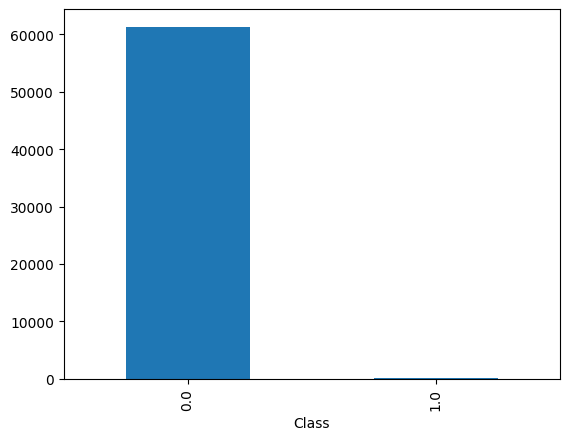

In [10]:
df["Class"].value_counts().plot(kind="bar")

## This dataset is imbalanced dataset. The number of records for class1 is way too less than number of records for class0.

## Separate X and Y features

In [11]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [12]:
x = df.drop(columns=["Time","Class"])
y = df[["Class"]]

In [14]:
s=x.isna().sum()
s[s>0]

,0
Amount,1


## Data Preprocessing and Data cleaning

In [15]:
pre = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler()
).set_output(transform="pandas")

In [16]:
xpre = pre.fit_transform(x)
xpre.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.603905,-0.038487,1.286554,0.874001,-0.054835,0.275584,0.284552,0.034578,0.263642,0.122347,...,0.272416,0.013550,0.604869,-0.118825,0.102146,-0.017275,-0.419736,0.342711,-0.079026,0.201702
1,0.768846,0.166819,-0.362031,0.201207,0.232262,-0.141688,0.029162,0.023170,-0.261846,-0.110462,...,-0.157178,-0.274099,-0.834070,0.238751,-0.579481,0.070812,0.212131,-0.029643,0.031577,-0.345235
2,-0.603123,-0.806197,0.755681,0.151742,-0.173669,1.300563,0.727200,0.159582,-1.330479,0.227882,...,0.639107,0.382775,1.380211,1.603331,-1.165025,-1.057474,-0.319406,-0.150772,-0.198662,1.054289
3,-0.392190,-0.106600,0.769444,-0.747537,0.181575,0.876744,0.282956,0.268460,-1.222167,-0.009287,...,-0.343434,-0.111224,0.176938,-0.253653,-1.979904,1.165792,-0.485556,0.157671,0.176051,0.104472
4,-0.495462,0.537284,0.599515,0.168565,-0.104474,-0.005125,0.567967,-0.275233,0.648885,0.720501,...,0.483034,0.025857,1.421972,-0.164390,0.226715,-0.780125,0.967135,0.567008,0.651193,-0.094715


## Split the dataset into training and testing

In [17]:
xtrain,xtest,ytrain,ytest = train_test_split(xpre,y,train_size=0.8,random_state=21)

## Imbalanced datasets can be handled by SMOTE (Synthetic Minority Oversampling Technique)
SMOTE is a ML technique which creates synthetic samples for minority classes(minority class refers to the class which has very few datapoints/records)

In [18]:
smote = SMOTE(sampling_strategy='minority')
x_resampled,y_resampled = smote.fit_resample(xtrain,ytrain)

In [19]:
y_resampled.value_counts()

,count
Class,
0.0,49056
1.0,49056


## Using Isolation Forest model to identify the anamolies in the data

In [20]:
x_resampled[0:1]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.545849,-0.505044,0.245587,0.276738,-0.662262,0.04617,-0.395296,0.082235,0.307689,-0.010864,...,0.48879,0.566949,1.223284,-0.391535,0.138328,0.016127,1.074542,-0.075647,0.155164,0.44433


In [21]:
import numpy as np
colors = np.random.rand(29)

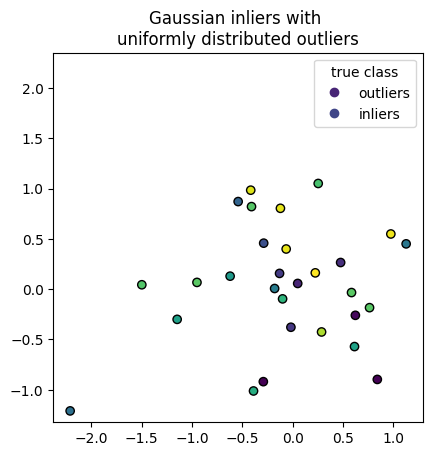

In [ ]:
import matplotlib.pyplot as plt

scatter = plt.scatter(x_resampled[0:1], x_resampled[1:2],c=colors, edgecolor="k")
handles, labels = scatter.legend_elements()
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.title("Gaussian inliers with \nuniformly distributed outliers")
plt.show()

In [22]:
model = IsolationForest(n_estimators=100,contamination='auto',random_state=21)
model.fit(x_resampled)

IsolationForest(random_state=21)

In [23]:
anomaly = model.predict(x_resampled)
anomaly

array([ 1,  1,  1, ..., -1,  1, -1])

In [26]:
# Calculate anomaly scores and classify anomalies
data = x_resampled.loc[x_resampled.index].copy()
data['anomaly_score'] = model.decision_function(x_resampled)
data['anomaly'] = model.predict(x_resampled)

data['anomaly'].value_counts()

,count
anomaly,
1,82070
-1,16042


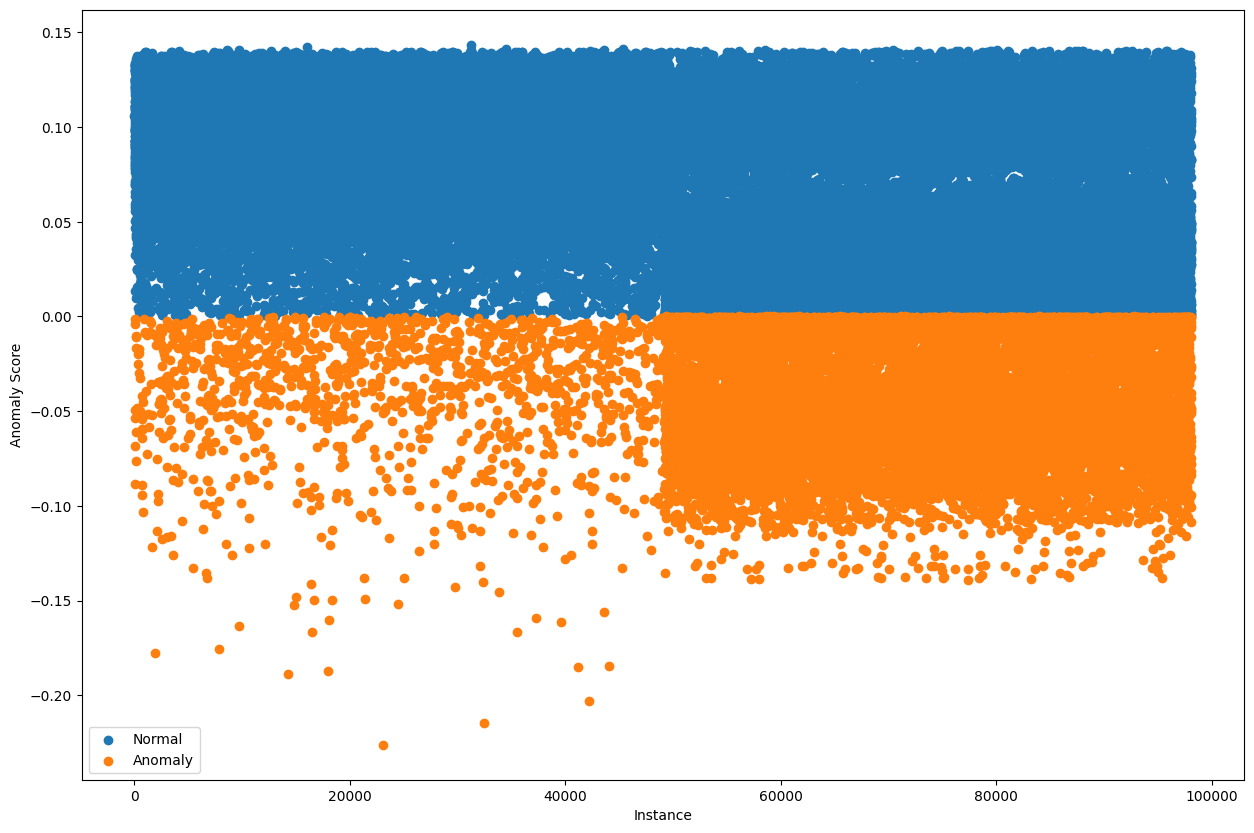

In [27]:
#Visualize the plots
# Visualization of the results
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))

# Plot normal instances
normal = data[data['anomaly'] == 1]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = data[data['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='Anomaly')
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [29]:
#Anomalies in data are:
df_anomaly = data[data["anomaly"]==-1]
df_anomaly

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,anomaly_score,anomaly
16,-0.654582,-0.594227,-0.306269,-1.360992,0.929875,3.237020,1.533671,0.487849,-0.367490,-0.978553,...,-0.686124,1.583187,1.588884,0.744651,0.628047,-0.906849,-0.412401,1.524432,-0.001377,-1
42,-3.231417,-7.965046,-3.518922,1.838895,-3.295172,0.155176,4.057165,-1.125344,-0.985374,-1.082967,...,-2.448876,-6.101943,1.028643,-1.895654,-1.014639,-2.002664,2.129487,14.460041,-0.088510,-1
57,-1.479224,-5.242561,-1.807124,0.357399,-2.647003,0.581122,1.413837,-0.451799,-1.357815,0.353702,...,-1.390506,-3.601808,0.233926,-0.846372,-0.496553,-1.005889,1.235142,8.251988,-0.049501,-1
58,-2.830827,0.641876,-1.728606,0.264756,-3.122659,0.983963,-2.495656,0.401088,0.619629,-1.462875,...,1.238106,1.102768,0.214667,-0.898575,2.062294,-0.393459,-3.447718,0.416784,-0.003789,-1
69,-1.622781,-5.015492,-1.396088,0.958310,-2.550771,0.845274,1.567423,-0.288332,-0.448472,-0.442961,...,-2.876952,-3.030749,0.611621,-2.473233,1.293780,-1.127634,1.257696,8.289287,-0.068215,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98100,-13.392799,8.648274,-19.062130,4.466050,-13.199952,-3.632727,-14.275968,13.838073,-3.247402,-7.471412,...,-2.736006,-1.922709,0.251052,3.697803,-0.481737,3.694019,1.272733,0.016958,-0.000207,-1
98102,-12.706718,8.329891,-18.347072,4.426256,-12.602184,-3.578621,-13.836895,13.174186,-3.288605,-7.589829,...,-2.568851,-1.771301,0.237048,3.473301,-0.483834,3.807871,1.318394,0.016958,-0.000705,-1
98103,-1.235996,4.181220,-9.792247,7.245344,-1.832572,-2.400606,-7.226783,2.631458,-4.868423,-10.771170,...,0.579334,0.363266,-1.993723,-1.239376,1.240736,5.103796,2.544039,-0.351526,-0.043251,-1
98109,-0.842842,3.079547,-8.178510,5.562619,-2.814405,-1.910633,-7.795525,2.445869,-3.464839,-10.401303,...,0.771330,0.916379,-1.525929,-3.511160,1.051011,5.122438,2.264267,-0.351526,-0.027099,-1


In [30]:
df_anomaly.to_csv("Anomaly Files.csv",index=False)